In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import igraph as ig
import seaborn as sns

In [2]:
phases = ["All", "G1", "S", "G2M"]

# TotalX Loading

- d = 3, per phase

In [ ]:
TX_MF_ind_df = pd.read_csv("../TotalX/HEK293T-Cell-Cycle/Results/ind_MF.csv", index_col=0)
TX_MF_int_df = pd.read_csv("../TotalX/HEK293T-Cell-Cycle/Results/int_MF.csv", index_col=0)
TX_corr_df = pd.read_csv("../TotalX/HEK293T-Cell-Cycle/Results/corr.csv", index_col=0)

In [ ]:
# get RNA names
TX_miRNA_names = [x.split('_')[0] for x in TX_MF_ind_df.columns if "All_status" in x]
TX_mRNA_names = TX_MF_ind_df.index.tolist()

# SmartSeqTotal Loading

In [125]:
ST_MF_ind_df = pd.read_csv("../Latent-Experiments/Cell-Cycle-Investigation/Results/independent_MF_concat.csv", index_col=0)
ST_MF_int_df = pd.read_csv("../Latent-Experiments/Cell-Cycle-Investigation/Results/interacting_MF_concat.csv", index_col=0)
ST_corr_df = pd.read_csv("../Latent-Experiments/Cell-Cycle-Investigation/Results/corr_concat.csv", index_col=0)

In [126]:
# remove parameter settings
ST_MF_ind_df.columns = [x.replace("d3_c95_", "") for x in ST_MF_ind_df.columns]
ST_corr_df.columns = [x.replace("c95_", "") for x in ST_corr_df.columns]

# get RNA names
ST_miRNA_names = [x.split('_')[0] for x in ST_MF_ind_df.columns if "All_status" in x]
ST_mRNA_names = ST_MF_ind_df.index.tolist()

# remove parameter settings (select common confidence setting)
ST_MF_int_df = ST_MF_int_df[[x for x in ST_MF_int_df.columns if "c95_mc95" in x]]
ST_MF_int_df.columns = [x.replace("d3_N1000_c95_mc95_", "") for x in ST_MF_int_df.columns]

# add HAR midpoint columns
for miRNA in ST_miRNA_names:
    for phase in phases:
        ST_MF_int_df[f"{miRNA}_{phase}_HAR_mid"] = (ST_MF_int_df[f"{miRNA}_{phase}_HAR_min"] + ST_MF_int_df[f"{miRNA}_{phase}_HAR_min"]) / 2

# add missing rows (presumably mRNA not interacting with any miRNA, so don't appear in concat df)
ST_MF_int_df = ST_MF_int_df.reindex(ST_mRNA_names)

C:\Users\wjh20\AppData\Local\Temp\ipykernel_46340\863902406.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ST_MF_int_df[f"{miRNA}_{phase}_HAR_mid"] = (ST_MF_int_df[f"{miRNA}_{phase}_HAR_min"] + ST_MF_int_df[f"{miRNA}_{phase}_HAR_min"]) / 2


# Observed - Recovered Histogram

In [127]:
plt.rcParams.update({'font.size': 16})

## Single miRNA

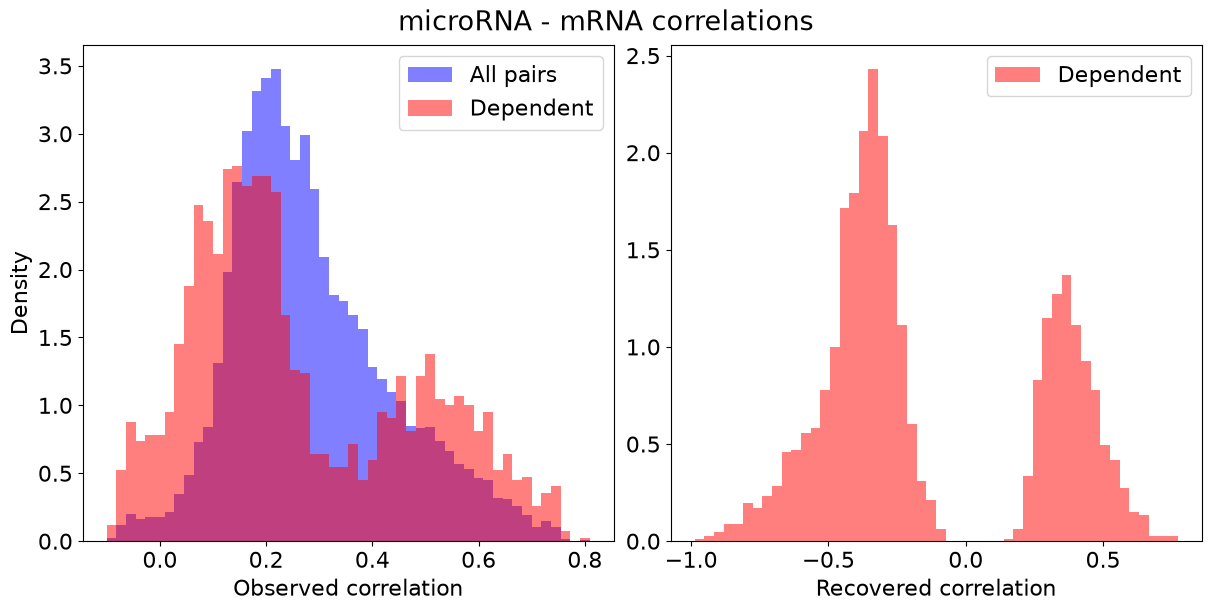

In [173]:
miRNA = "MIR4426"

fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

mask = (TX_MF_ind_df[f'{miRNA}_All_status'] == "INFEASIBLE").values.squeeze()
mid = TX_MF_int_df[f'{miRNA}_All_HAR_mid']
OB = TX_corr_df[f'{miRNA}_All_OB']

axs[0].hist(OB, bins=50, color="blue", alpha=0.5, density=True, label="All pairs")
axs[0].hist(OB[mask], bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[1].hist(mid[mask], bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")
axs[1].set_xlabel("Recovered correlation")

axs[0].legend()
axs[1].legend()

fig.suptitle("microRNA - mRNA correlations")

#axs[0].set_xlim(-0.2, 0.9)
#axs[1].set_xlim(-1, 1)

plt.show()

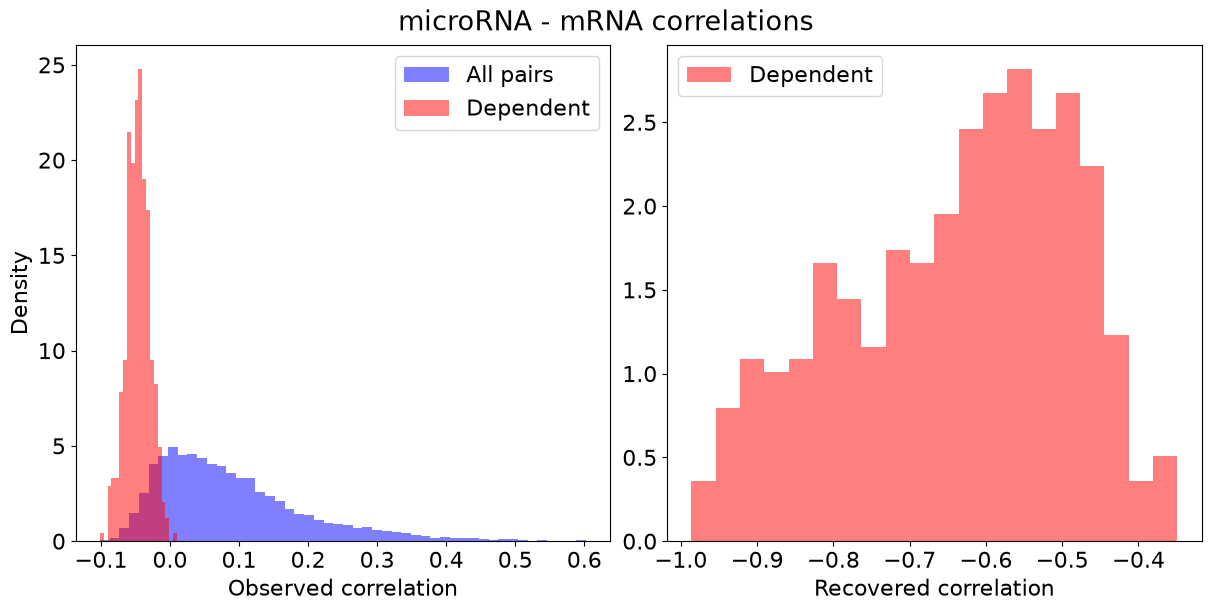

In [168]:
miRNA = ST_miRNA_names[13] # 10, 12, 13

fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

mask = (ST_MF_ind_df[f'{miRNA}_All_status'] == "INFEASIBLE").values.squeeze()
mid = ST_MF_int_df[f'{miRNA}_All_HAR_mid']
OB = ST_corr_df[f'{miRNA}_All_OB']

axs[0].hist(OB, bins=50, color="blue", alpha=0.5, density=True, label="All pairs")
axs[0].hist(OB[mask], bins=20, color="red", alpha=0.5, density=True, label="Dependent")

axs[1].hist(mid[mask], bins=20, color="red", alpha=0.5, density=True, label="Dependent")

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")
axs[1].set_xlabel("Recovered correlation")

axs[0].legend()
axs[1].legend()

fig.suptitle("microRNA - mRNA correlations")

#axs[0].set_xlim(-0.2, 0.9)
#axs[1].set_xlim(-1, 1)

plt.show()

### + shared xlim

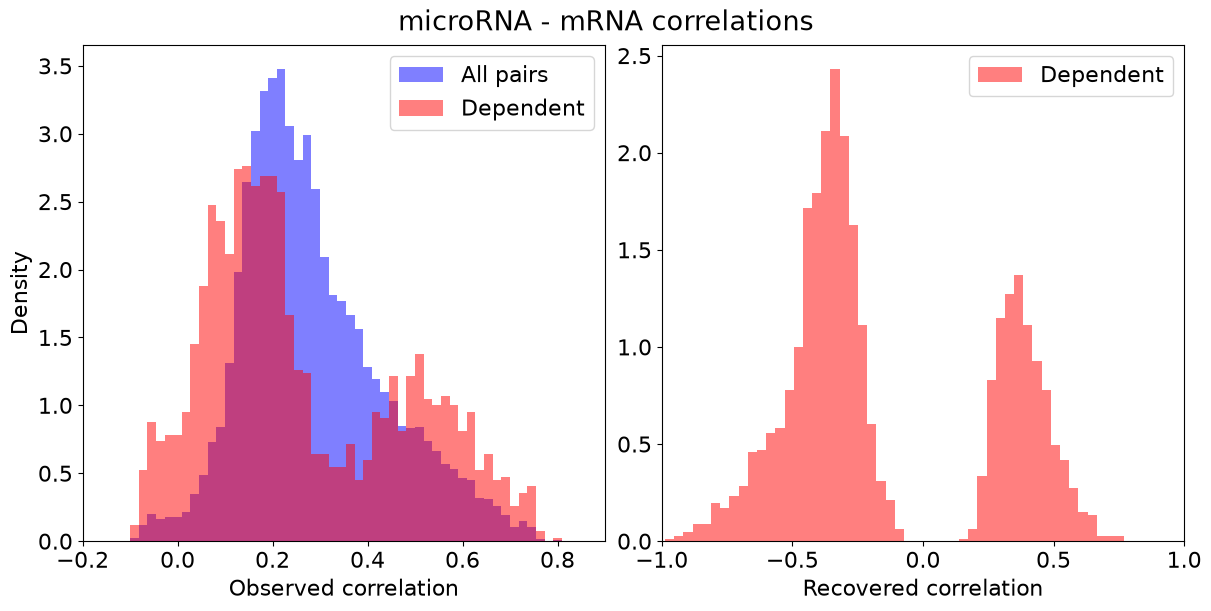

In [174]:
miRNA = "MIR4426"

fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

mask = (TX_MF_ind_df[f'{miRNA}_All_status'] == "INFEASIBLE").values.squeeze()
mid = TX_MF_int_df[f'{miRNA}_All_HAR_mid']
OB = TX_corr_df[f'{miRNA}_All_OB']

axs[0].hist(OB, bins=50, color="blue", alpha=0.5, density=True, label="All pairs")
axs[0].hist(OB[mask], bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[1].hist(mid[mask], bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")
axs[1].set_xlabel("Recovered correlation")

axs[0].legend()
axs[1].legend()

fig.suptitle("microRNA - mRNA correlations")

axs[0].set_xlim(-0.2, 0.9)
axs[1].set_xlim(-1, 1)

plt.show()

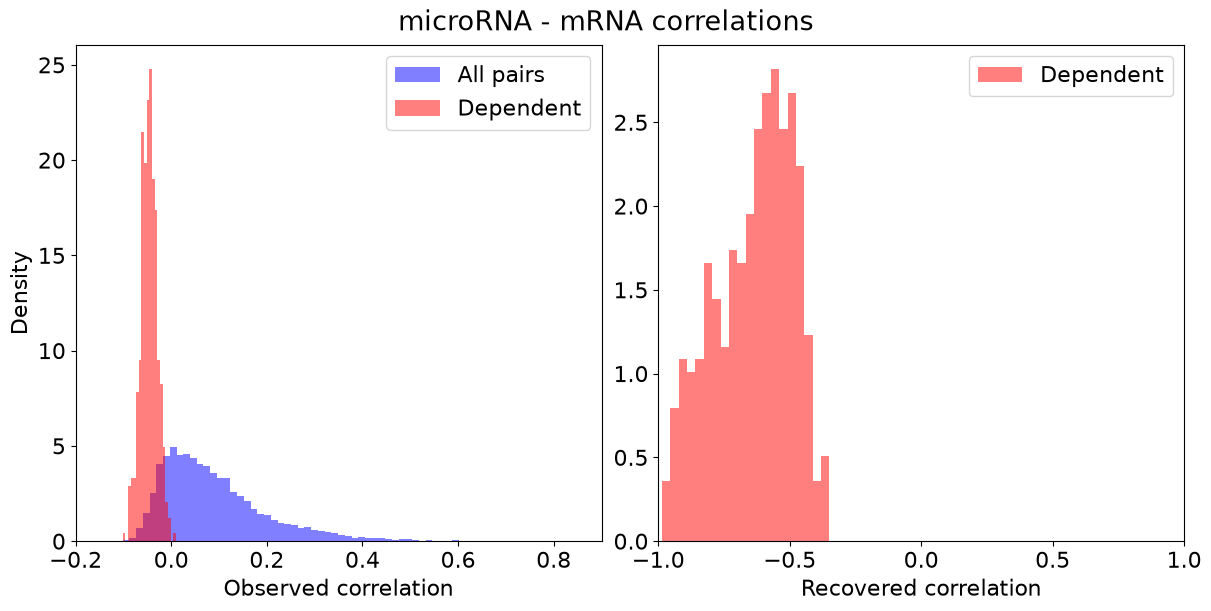

In [175]:
miRNA = ST_miRNA_names[13] # 10, 12, 13

fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

mask = (ST_MF_ind_df[f'{miRNA}_All_status'] == "INFEASIBLE").values.squeeze()
mid = ST_MF_int_df[f'{miRNA}_All_HAR_mid']
OB = ST_corr_df[f'{miRNA}_All_OB']

axs[0].hist(OB, bins=50, color="blue", alpha=0.5, density=True, label="All pairs")
axs[0].hist(OB[mask], bins=20, color="red", alpha=0.5, density=True, label="Dependent")

axs[1].hist(mid[mask], bins=20, color="red", alpha=0.5, density=True, label="Dependent")

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")
axs[1].set_xlabel("Recovered correlation")

axs[0].legend()
axs[1].legend()

fig.suptitle("microRNA - mRNA correlations")

axs[0].set_xlim(-0.2, 0.9)
axs[1].set_xlim(-1, 1)

plt.show()

## All miRNA

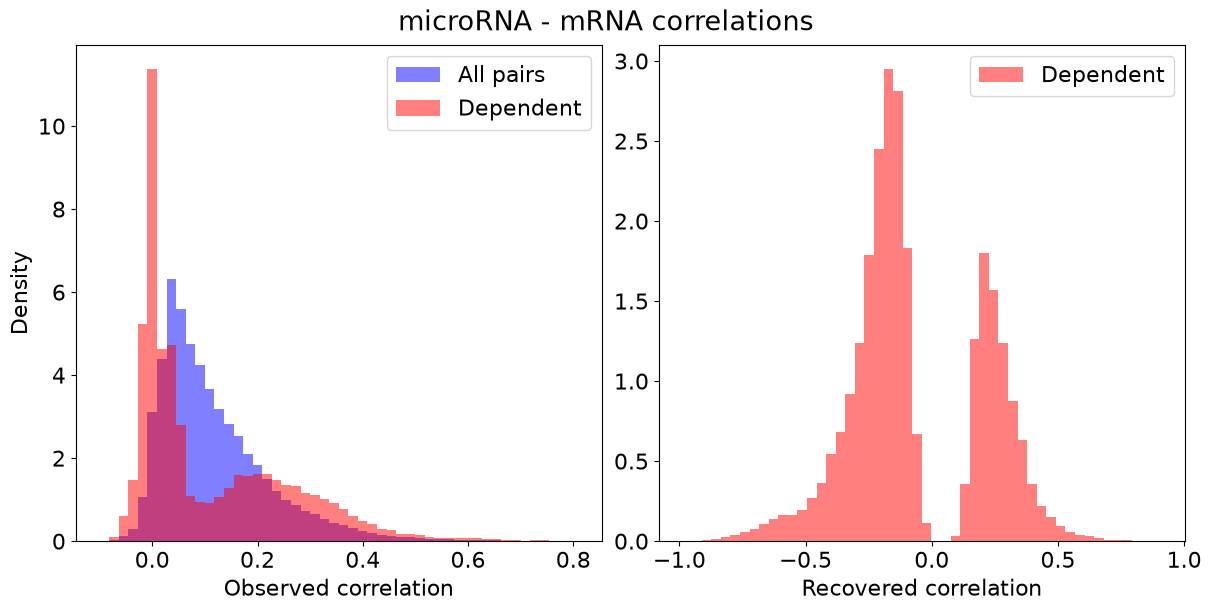

In [176]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

OB_all = []
OB_mask_all = []
mid_mask_all = []
for miRNA in TX_miRNA_names:
    mask = (TX_MF_ind_df[f'{miRNA}_All_status'] == "INFEASIBLE").values.squeeze()
    mid = TX_MF_int_df[f'{miRNA}_All_HAR_mid']
    OB = TX_corr_df[f'{miRNA}_All_OB']

    OB_all += OB.tolist()
    OB_mask_all += OB[mask].tolist()
    mid_mask_all += mid[mask].tolist()

axs[0].hist(OB_all, bins=50, color="blue", alpha=0.5, density=True, label="All pairs")
axs[0].hist(OB_mask_all, bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[1].hist(mid_mask_all, bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[0].legend()
axs[1].legend()

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")
axs[1].set_xlabel("Recovered correlation")

fig.suptitle("microRNA - mRNA correlations")

plt.show()

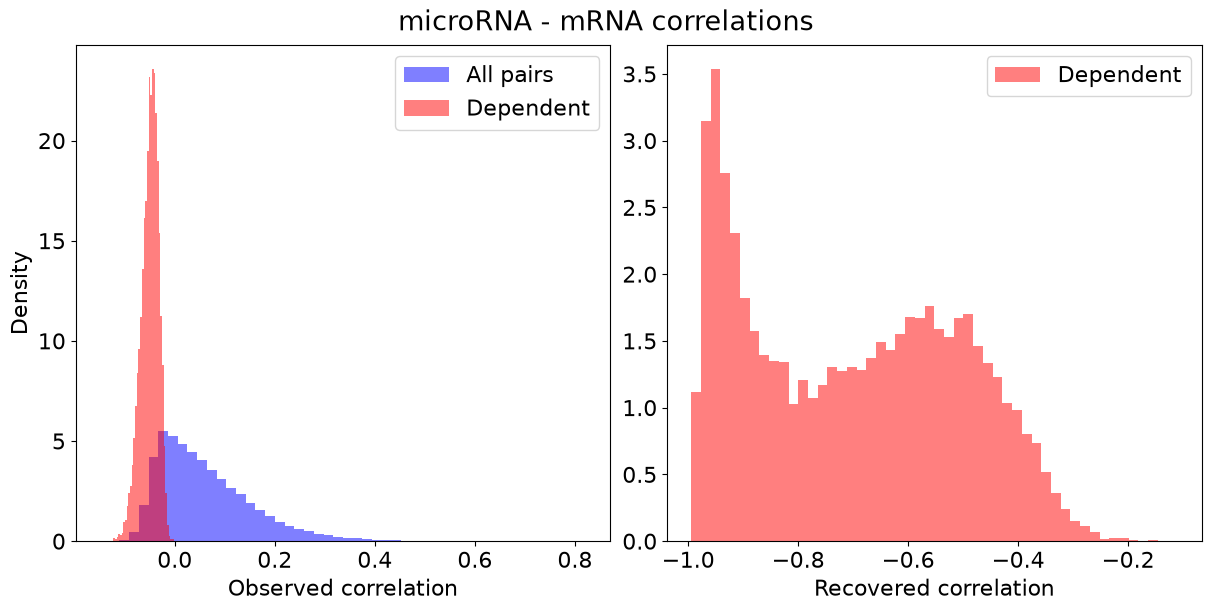

In [177]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

OB_all = []
OB_mask_all = []
mid_mask_all = []
for miRNA in ST_miRNA_names:
    mask = (ST_MF_ind_df[f'{miRNA}_All_status'] == "INFEASIBLE").values.squeeze()
    mid = ST_MF_int_df[f'{miRNA}_All_HAR_mid']
    OB = ST_corr_df[f'{miRNA}_All_OB']

    OB_all += OB.tolist()
    OB_mask_all += OB[mask].tolist()
    mid_mask_all += mid[mask].tolist()

axs[0].hist(OB_all, bins=50, color="blue", alpha=0.5, density=True, label="All pairs")
axs[0].hist(OB_mask_all, bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[1].hist(mid_mask_all, bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[0].legend()
axs[1].legend()

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")
axs[1].set_xlabel("Recovered correlation")

fig.suptitle("microRNA - mRNA correlations")

plt.show()

### + shared xlim

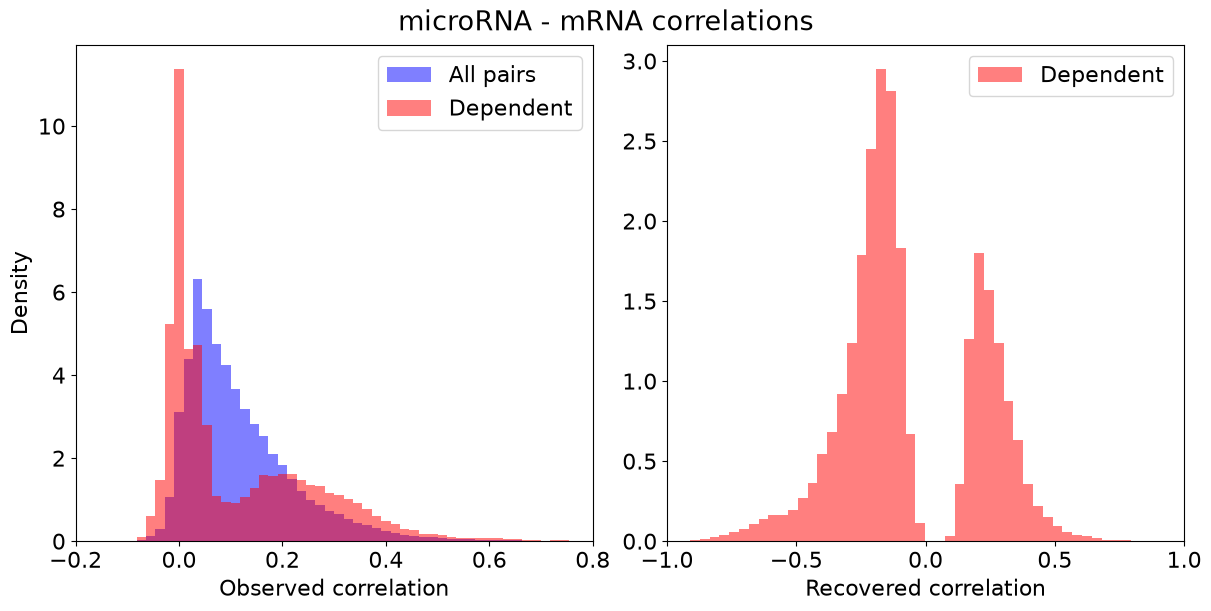

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

OB_all = []
OB_mask_all = []
mid_mask_all = []
for miRNA in TX_miRNA_names:
    mask = (TX_MF_ind_df[f'{miRNA}_All_status'] == "INFEASIBLE").values.squeeze()
    mid = TX_MF_int_df[f'{miRNA}_All_HAR_mid']
    OB = TX_corr_df[f'{miRNA}_All_OB']

    OB_all += OB.tolist()
    OB_mask_all += OB[mask].tolist()
    mid_mask_all += mid[mask].tolist()

axs[0].hist(OB_all, bins=50, color="blue", alpha=0.5, density=True, label="All pairs")
axs[0].hist(OB_mask_all, bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[1].hist(mid_mask_all, bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[0].legend()
axs[1].legend()

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")
axs[1].set_xlabel("Recovered correlation")

axs[0].set_xlim(-0.2, 0.8)
axs[1].set_xlim(-1, 1)

fig.suptitle("microRNA - mRNA correlations")

plt.show()

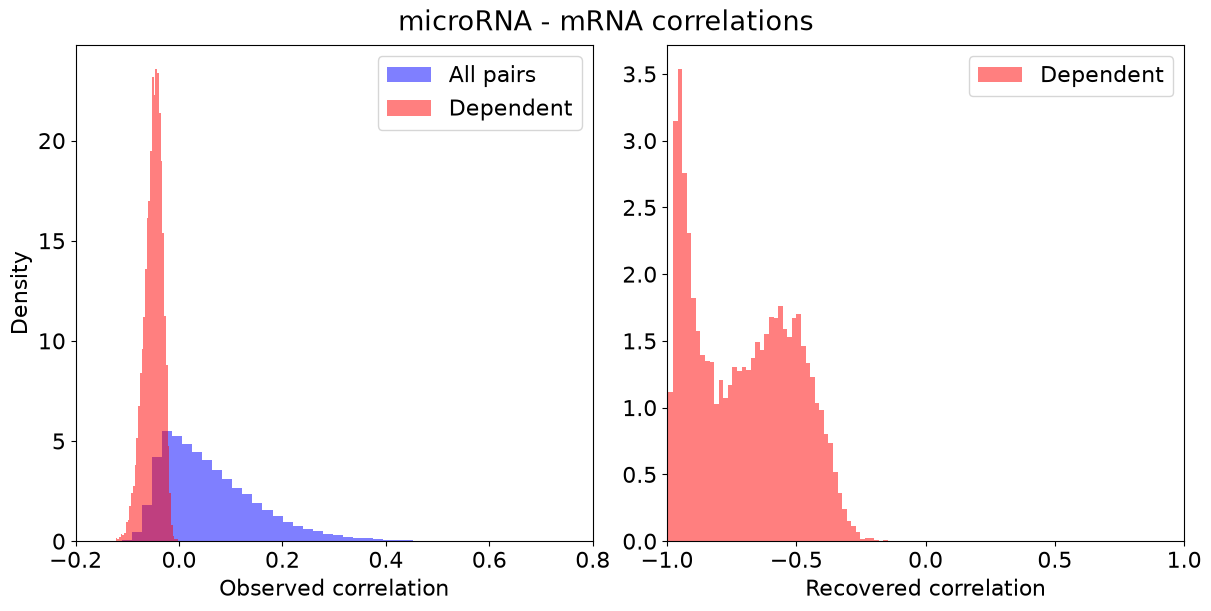

In [180]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

OB_all = []
OB_mask_all = []
mid_mask_all = []
for miRNA in ST_miRNA_names:
    mask = (ST_MF_ind_df[f'{miRNA}_All_status'] == "INFEASIBLE").values.squeeze()
    mid = ST_MF_int_df[f'{miRNA}_All_HAR_mid']
    OB = ST_corr_df[f'{miRNA}_All_OB']

    OB_all += OB.tolist()
    OB_mask_all += OB[mask].tolist()
    mid_mask_all += mid[mask].tolist()

axs[0].hist(OB_all, bins=50, color="blue", alpha=0.5, density=True, label="All pairs")
axs[0].hist(OB_mask_all, bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[1].hist(mid_mask_all, bins=50, color="red", alpha=0.5, density=True, label="Dependent")

axs[0].legend()
axs[1].legend()

axs[0].set_xlabel("Observed correlation")
axs[0].set_ylabel("Density")
axs[1].set_xlabel("Recovered correlation")

axs[0].set_xlim(-0.2, 0.8)
axs[1].set_xlim(-1, 1)

fig.suptitle("microRNA - mRNA correlations")

plt.show()

# Phase Dependence Table

In [181]:
# select all categories
miRNA_names = TX_miRNA_names
phase_names = phases

# table of miRNA x phases
ind_table = pd.DataFrame(
    index=["Total"] + miRNA_names,
    columns=phase_names,
    dtype=float
)

# fill
for phase in phase_names:
    for miRNA in miRNA_names:
        ind_table.loc[miRNA, phase] = (TX_MF_ind_df[f'{miRNA}_{phase}_status'] == "INFEASIBLE").mean() * 100
    ind_table.loc['Total', phase] = ind_table.loc[miRNA_names, phase].mean()

# display
ind_table.style.format(precision=2).background_gradient(axis=1, cmap="Blues")

,All,G1,S,G2M
Total,20.43,15.43,8.56,8.62
MIR3917,0.63,38.01,0.87,0.58
MIR5087,2.29,11.74,0.98,1.18
MIR3658,18.37,11.06,4.19,4.75
MIR4426,22.42,13.51,11.27,4.96
MIR4444-1,10.47,5.47,1.17,3.33
MIR1244-1,20.34,12.52,10.12,5.23
MIR3655,9.22,6.49,3.22,2.47
MIR4647,7.20,11.84,1.63,1.71
MIR3654,29.50,8.80,4.14,2.53


In [182]:
# select all categories
miRNA_names = ST_miRNA_names
phase_names = phases

# table of miRNA x phases
ind_table = pd.DataFrame(
    index=["Total"] + miRNA_names,
    columns=phase_names,
    dtype=float
)

# fill
for phase in phase_names:
    for miRNA in miRNA_names:
        ind_table.loc[miRNA, phase] = (ST_MF_ind_df[f'{miRNA}_{phase}_status'] == "INFEASIBLE").mean() * 100
    ind_table.loc['Total', phase] = ind_table.loc[miRNA_names, phase].mean()

# display
ind_table.style.format(precision=2).background_gradient(axis=1, cmap="Blues")

,All,G1,S,G2M
Total,7.85,8.12,9.05,7.78
MIR100,11.11,13.19,17.67,13.25
MIR103A2,18.10,19.84,18.79,21.50
MIR16-2,2.52,6.60,2.07,3.82
MIR199A1,23.31,0.02,22.69,20.26
MIR199A2,9.46,14.07,14.93,8.55
MIR221,7.79,7.58,15.83,6.94
MIR222,0.87,0.22,0.84,0.26
MIR23A,1.89,1.24,1.85,1.44
MIR24-2,3.75,6.12,5.66,3.43


# Phase Observed - Recovered Violins

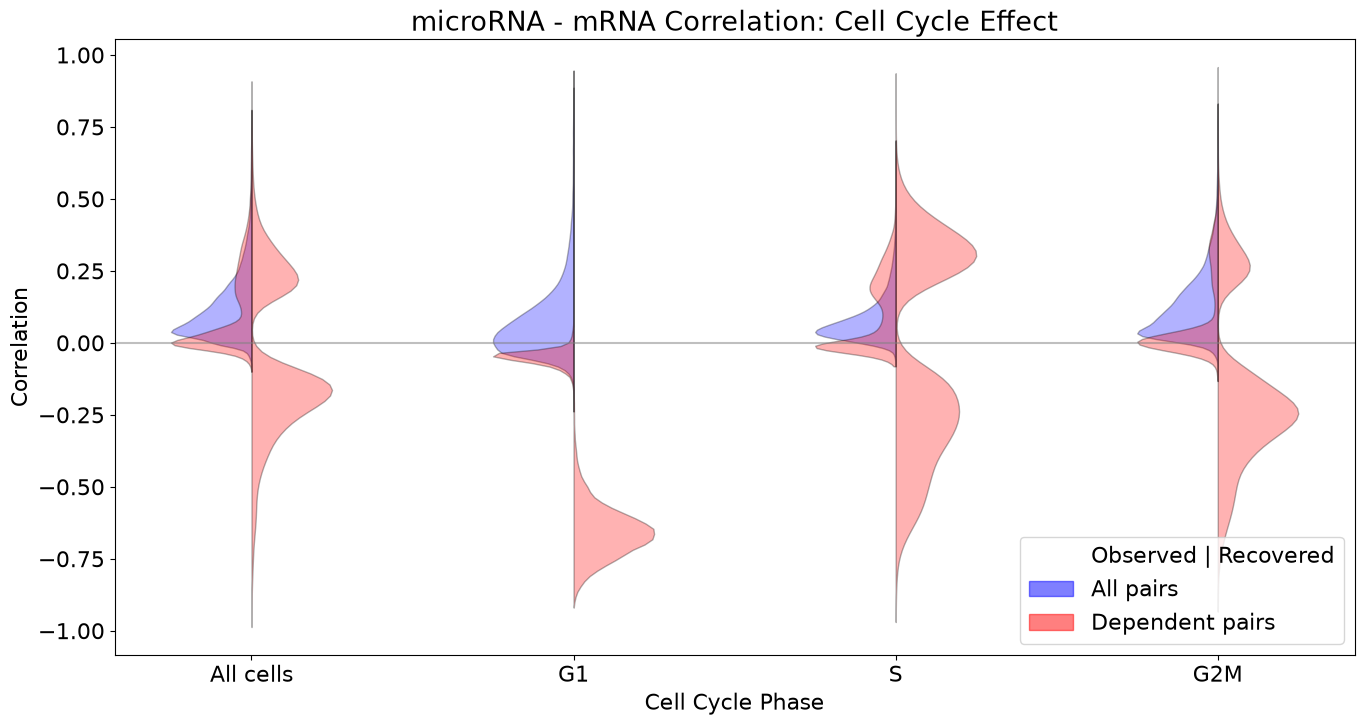

In [183]:
miRNA_names = TX_miRNA_names

all_corr_HR = TX_MF_int_df[[f"{miRNA}_All_HAR_mid" for miRNA in miRNA_names]].values.flatten()
all_mask = ~np.isnan(all_corr_HR)
all_corr_HR = all_corr_HR[all_mask]

G1_corr_HR = TX_MF_int_df[[f"{miRNA}_G1_HAR_mid" for miRNA in miRNA_names]].values.flatten()
G1_mask = ~np.isnan(G1_corr_HR)
G1_corr_HR = G1_corr_HR[G1_mask]

S_corr_HR = TX_MF_int_df[[f"{miRNA}_S_HAR_mid" for miRNA in miRNA_names]].values.flatten()
S_mask = ~np.isnan(S_corr_HR)
S_corr_HR = S_corr_HR[S_mask]

G2M_corr_HR = TX_MF_int_df[[f"{miRNA}_G2M_HAR_mid" for miRNA in miRNA_names]].values.flatten()
G2M_mask = ~np.isnan(G2M_corr_HR)
G2M_corr_HR = G2M_corr_HR[G2M_mask]

all_corr_OB = TX_corr_df[[f"{miRNA}_All_OB" for miRNA in miRNA_names]].values.flatten()
all_corr_OB_int = all_corr_OB[all_mask]

G1_corr_OB = TX_corr_df[[f"{miRNA}_G1_OB" for miRNA in miRNA_names]].values.flatten()
G1_corr_OB_int = G1_corr_OB[G1_mask]

S_corr_OB = TX_corr_df[[f"{miRNA}_S_OB" for miRNA in miRNA_names]].values.flatten()
S_corr_OB_int = S_corr_OB[S_mask]

G2M_corr_OB = TX_corr_df[[f"{miRNA}_G2M_OB" for miRNA in miRNA_names]].values.flatten()
G2M_corr_OB_int = G2M_corr_OB[G2M_mask]

fig, axs = plt.subplots(figsize=(16, 8))

# all observed
plot_data_list = [
    all_corr_OB,
    G1_corr_OB,
    S_corr_OB,
    G2M_corr_OB
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="low"
    )
    vp['bodies'][0].set_facecolor("blue")
    vp['bodies'][0].set_edgecolor("black")

# interacting observed
plot_data_list = [
    all_corr_OB_int,
    G1_corr_OB_int,
    S_corr_OB_int,
    G2M_corr_OB_int
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="low"
    )
    vp['bodies'][0].set_facecolor("red")
    vp['bodies'][0].set_edgecolor("black")

# interacting recovered
plot_data_list = [
    all_corr_HR,
    G1_corr_HR,
    S_corr_HR,
    G2M_corr_HR
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="high"
    )
    vp['bodies'][0].set_facecolor("red")
    vp['bodies'][0].set_edgecolor("black")


plt.axvspan(0, 0, 0, 0, color="white", label="Observed | Recovered")
plt.axvspan(0, 0, 0, 0, alpha=0.5, color="blue", label="All pairs")
plt.axvspan(0, 0, 0, 0, alpha=0.5, color="red", label="Dependent pairs")
axs.legend()

axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
axs.set_xlabel("Cell Cycle Phase")
axs.set_ylabel(f"Correlation")
axs.set_title("microRNA - mRNA Correlation: Cell Cycle Effect")
plt.show()

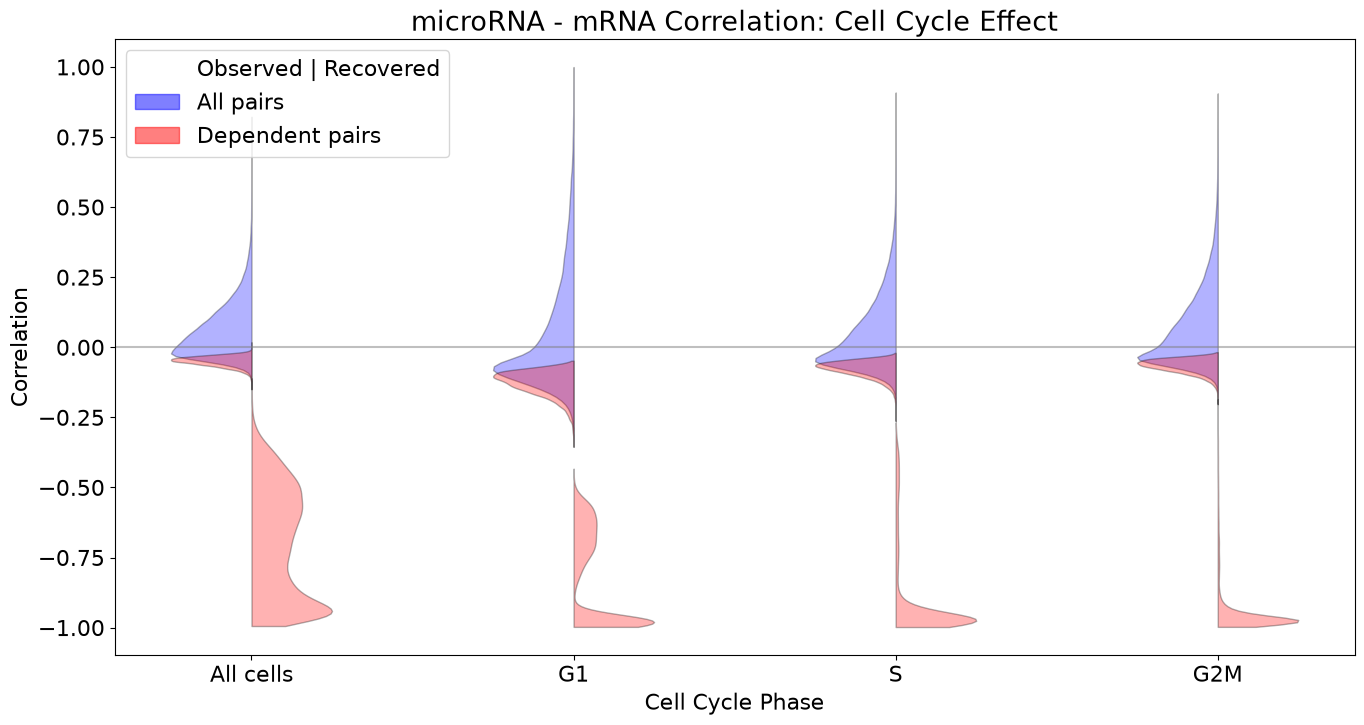

In [186]:
miRNA_names = ST_miRNA_names

all_corr_HR = ST_MF_int_df[[f"{miRNA}_All_HAR_mid" for miRNA in miRNA_names]].values.flatten()
all_mask = ~np.isnan(all_corr_HR)
all_corr_HR = all_corr_HR[all_mask]

G1_corr_HR = ST_MF_int_df[[f"{miRNA}_G1_HAR_mid" for miRNA in miRNA_names]].values.flatten()
G1_mask = ~np.isnan(G1_corr_HR)
G1_corr_HR = G1_corr_HR[G1_mask]

S_corr_HR = ST_MF_int_df[[f"{miRNA}_S_HAR_mid" for miRNA in miRNA_names]].values.flatten()
S_mask = ~np.isnan(S_corr_HR)
S_corr_HR = S_corr_HR[S_mask]

G2M_corr_HR = ST_MF_int_df[[f"{miRNA}_G2M_HAR_mid" for miRNA in miRNA_names]].values.flatten()
G2M_mask = ~np.isnan(G2M_corr_HR)
G2M_corr_HR = G2M_corr_HR[G2M_mask]

all_corr_OB = ST_corr_df[[f"{miRNA}_All_OB" for miRNA in miRNA_names]].values.flatten()
all_corr_OB_int = all_corr_OB[all_mask]

G1_corr_OB = ST_corr_df[[f"{miRNA}_G1_OB" for miRNA in miRNA_names]].values.flatten()
G1_corr_OB_int = G1_corr_OB[G1_mask]

S_corr_OB = ST_corr_df[[f"{miRNA}_S_OB" for miRNA in miRNA_names]].values.flatten()
S_corr_OB_int = S_corr_OB[S_mask]

G2M_corr_OB = ST_corr_df[[f"{miRNA}_G2M_OB" for miRNA in miRNA_names]].values.flatten()
G2M_corr_OB_int = G2M_corr_OB[G2M_mask]

fig, axs = plt.subplots(figsize=(16, 8))

# all observed
plot_data_list = [
    all_corr_OB,
    G1_corr_OB,
    S_corr_OB,
    G2M_corr_OB
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="low"
    )
    vp['bodies'][0].set_facecolor("blue")
    vp['bodies'][0].set_edgecolor("black")

# interacting observed
plot_data_list = [
    all_corr_OB_int,
    G1_corr_OB_int,
    S_corr_OB_int,
    G2M_corr_OB_int
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="low"
    )
    vp['bodies'][0].set_facecolor("red")
    vp['bodies'][0].set_edgecolor("black")

# interacting recovered
plot_data_list = [
    all_corr_HR,
    G1_corr_HR,
    S_corr_HR,
    G2M_corr_HR
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="high"
    )
    vp['bodies'][0].set_facecolor("red")
    vp['bodies'][0].set_edgecolor("black")


plt.axvspan(0, 0, 0, 0, color="white", label="Observed | Recovered")
plt.axvspan(0, 0, 0, 0, alpha=0.5, color="blue", label="All pairs")
plt.axvspan(0, 0, 0, 0, alpha=0.5, color="red", label="Dependent pairs")
axs.legend()

axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
axs.set_xlabel("Cell Cycle Phase")
axs.set_ylabel(f"Correlation")
axs.set_title("microRNA - mRNA Correlation: Cell Cycle Effect")
plt.show()

# Phase Correlation Networks

In [201]:
def construct_network(dataset, phase, G1, G2, k, K, d, D, t, plot=False):

    if dataset == "TX":
        miRNA_names = TX_miRNA_names
        mRNA_names = TX_mRNA_names
        int_df = TX_MF_int_df
    elif dataset == "ST":
        miRNA_names = ST_miRNA_names
        mRNA_names = ST_mRNA_names
        int_df = ST_MF_int_df
    else:
        raise Exception("Invalid dataset")

    # select named miRNA & mRNA
    miRNA_names = [miRNA_names[i] for i in G1]
    mRNA_names = [mRNA_names[i] for i in G2]

    corr_df = int_df.loc[mRNA_names, [f'{miRNA}_{phase}_HAR_mid' for miRNA in miRNA_names]]

    # select mRNA with [k, K] interactions
    mask = (k <= corr_df.notna().sum(axis=1)) & (corr_df.notna().sum(axis=1) <= K)
    corr_df = corr_df[mask]

    # select mRNA with [d, D] interactions above threshold t
    mask_thresh = ((t <= corr_df) | (corr_df <= -t)).sum(axis=1)
    mask = (d <= mask_thresh) & (mask_thresh <= D)
    corr_df = corr_df[mask]

    # size
    N_mRNA, N_miRNA = corr_df.shape
    corrs = np.array(corr_df)

    # construct edges
    idxs = np.where(~np.isnan(corrs))
    edges = [(int(j), N_miRNA + int(i)) for i, j in zip(*idxs)]

    # get edge correlations
    corrs = corrs[idxs]

    # total vertices
    vertices = N_miRNA + N_mRNA

    # color, label, size different for miRNA vs mRNA
    vertex_color = ["orange"] * N_miRNA + ["black"] * N_mRNA
    vertex_size = [30] * N_miRNA + [5] * N_mRNA
    vertex_label = miRNA_names + [None] * N_mRNA

    # edge width: constant or can relate to correlation strength
    edge_width = [2 for c in corrs] # int(abs(c) * 10)

    # edge color: red for negative, blue for positive, alpha of strength
    edge_color = [(1, 0, 0, -c) if c < 0 else (0, 0, 1, c) for c in corrs]

    # display size
    print(f"{len(edges)} edges between {vertices} vertices")

    if plot:

        # construct graph
        g = ig.Graph(vertices, edges)

        fig, axs = plt.subplots(figsize=(16, 16))
        
        ig.plot(
            g,
            target=axs,
            #layout="large", # node layout algorithm
            vertex_size=vertex_size,
            vertex_color=vertex_color,
            vertex_frame_width=1,
            vertex_label=vertex_label,
            vertex_label_size=10,
            edge_width=edge_width,
            edge_color=edge_color
        )
        plt.show()

## TX

162 edges between 90 vertices


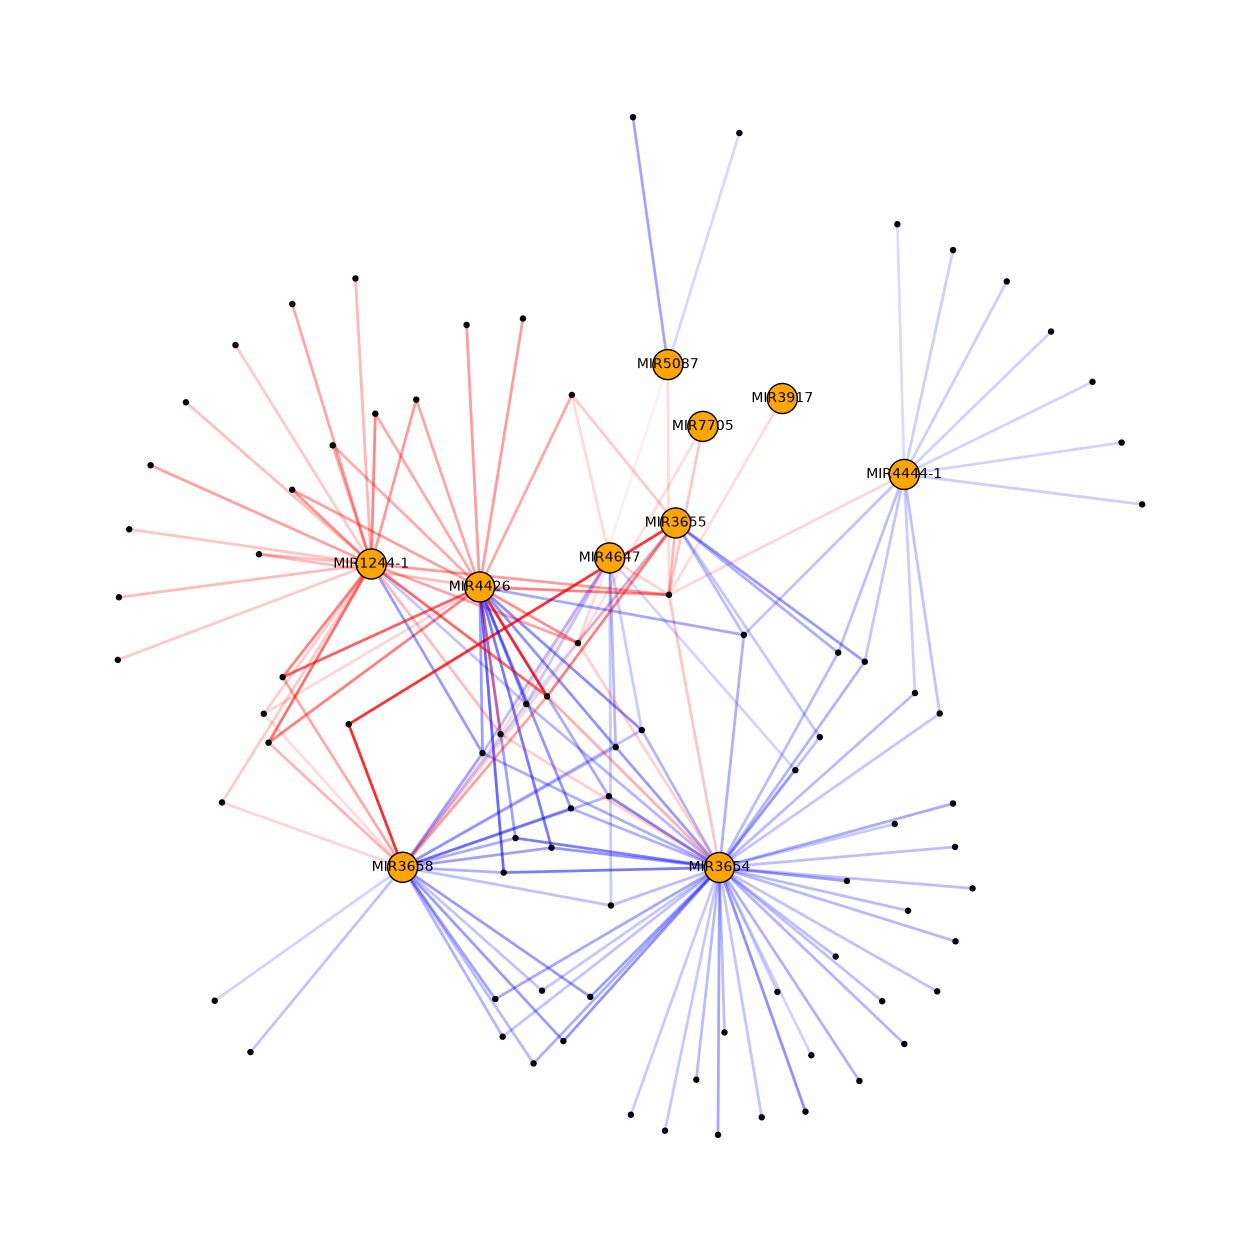

178 edges between 116 vertices


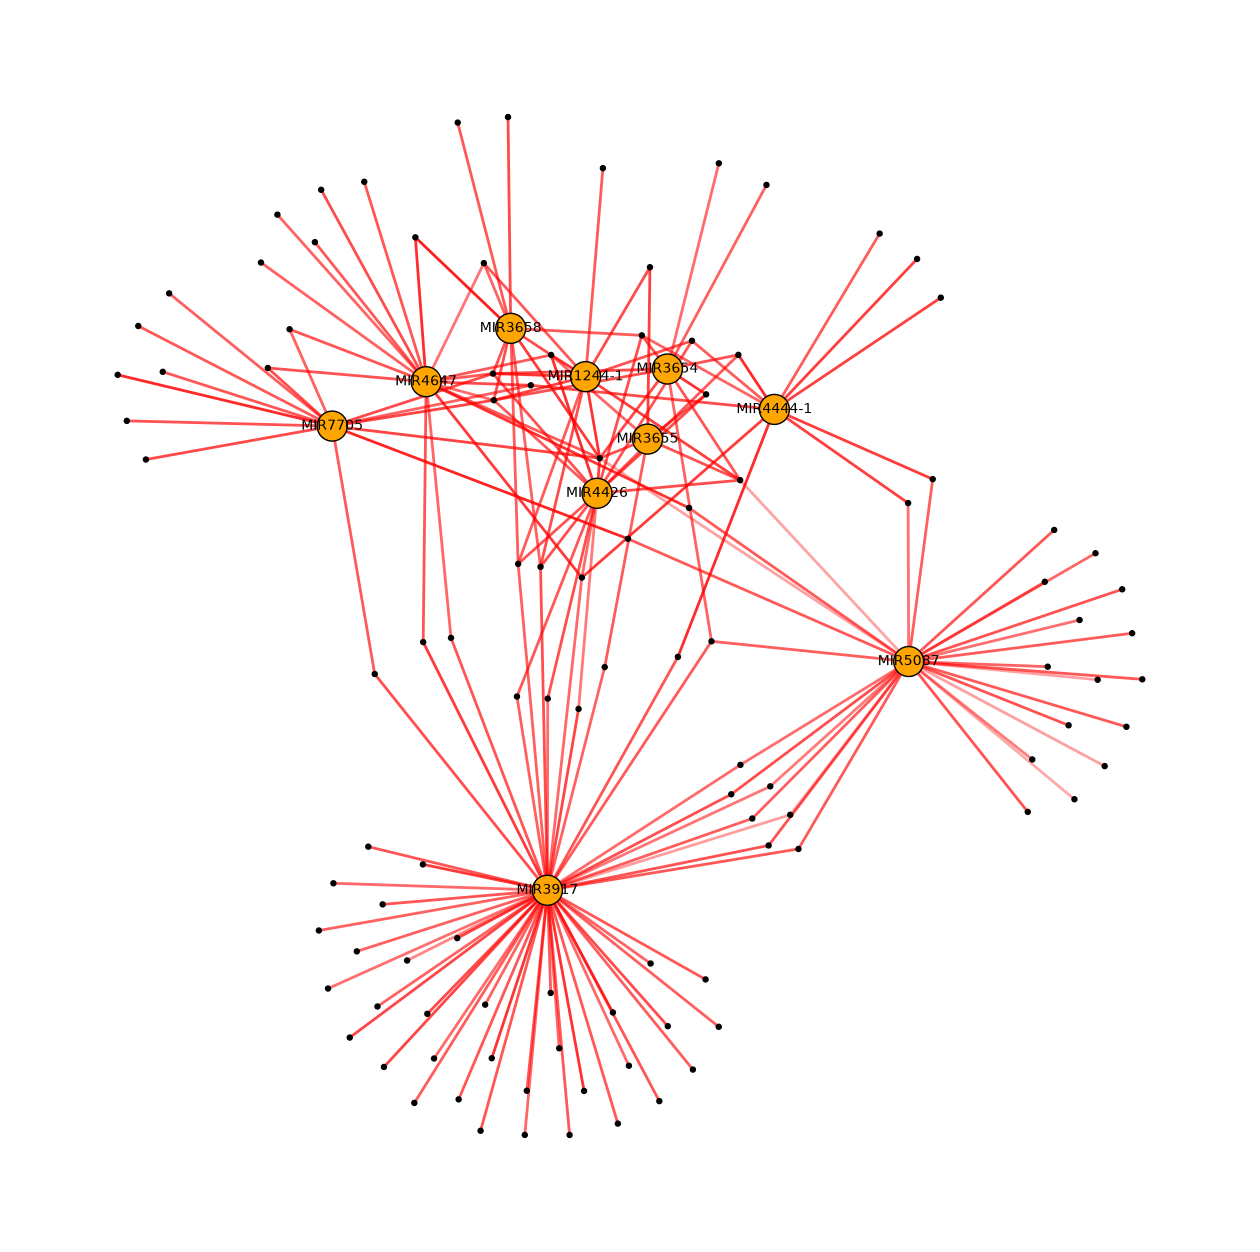

40 edges between 32 vertices


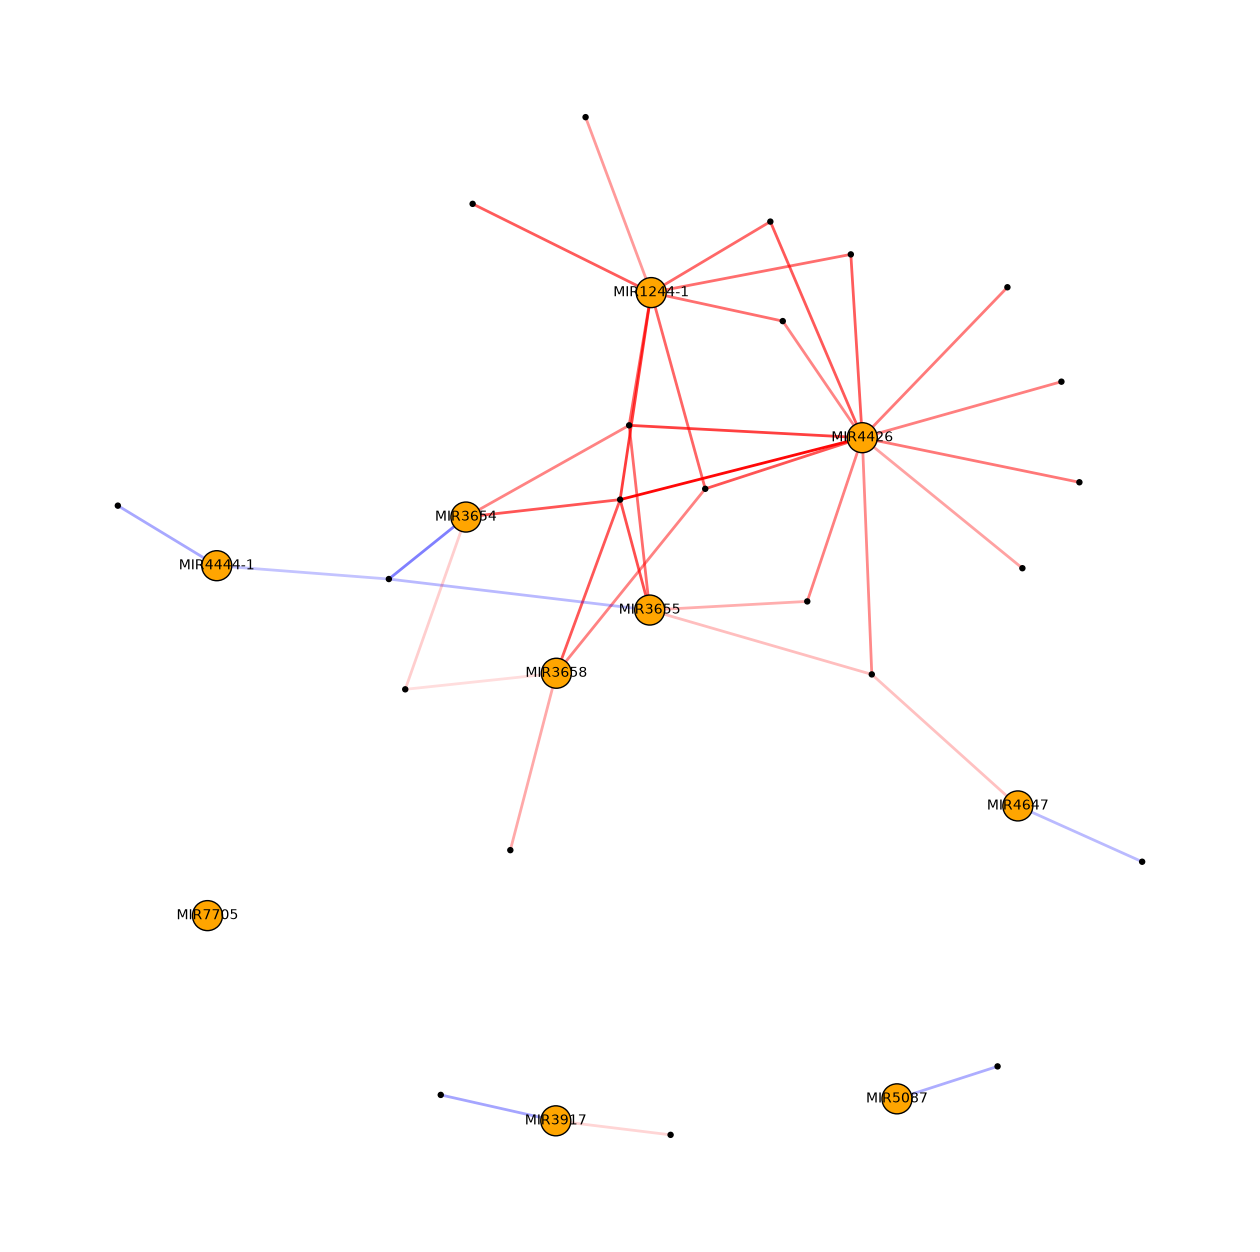

28 edges between 24 vertices


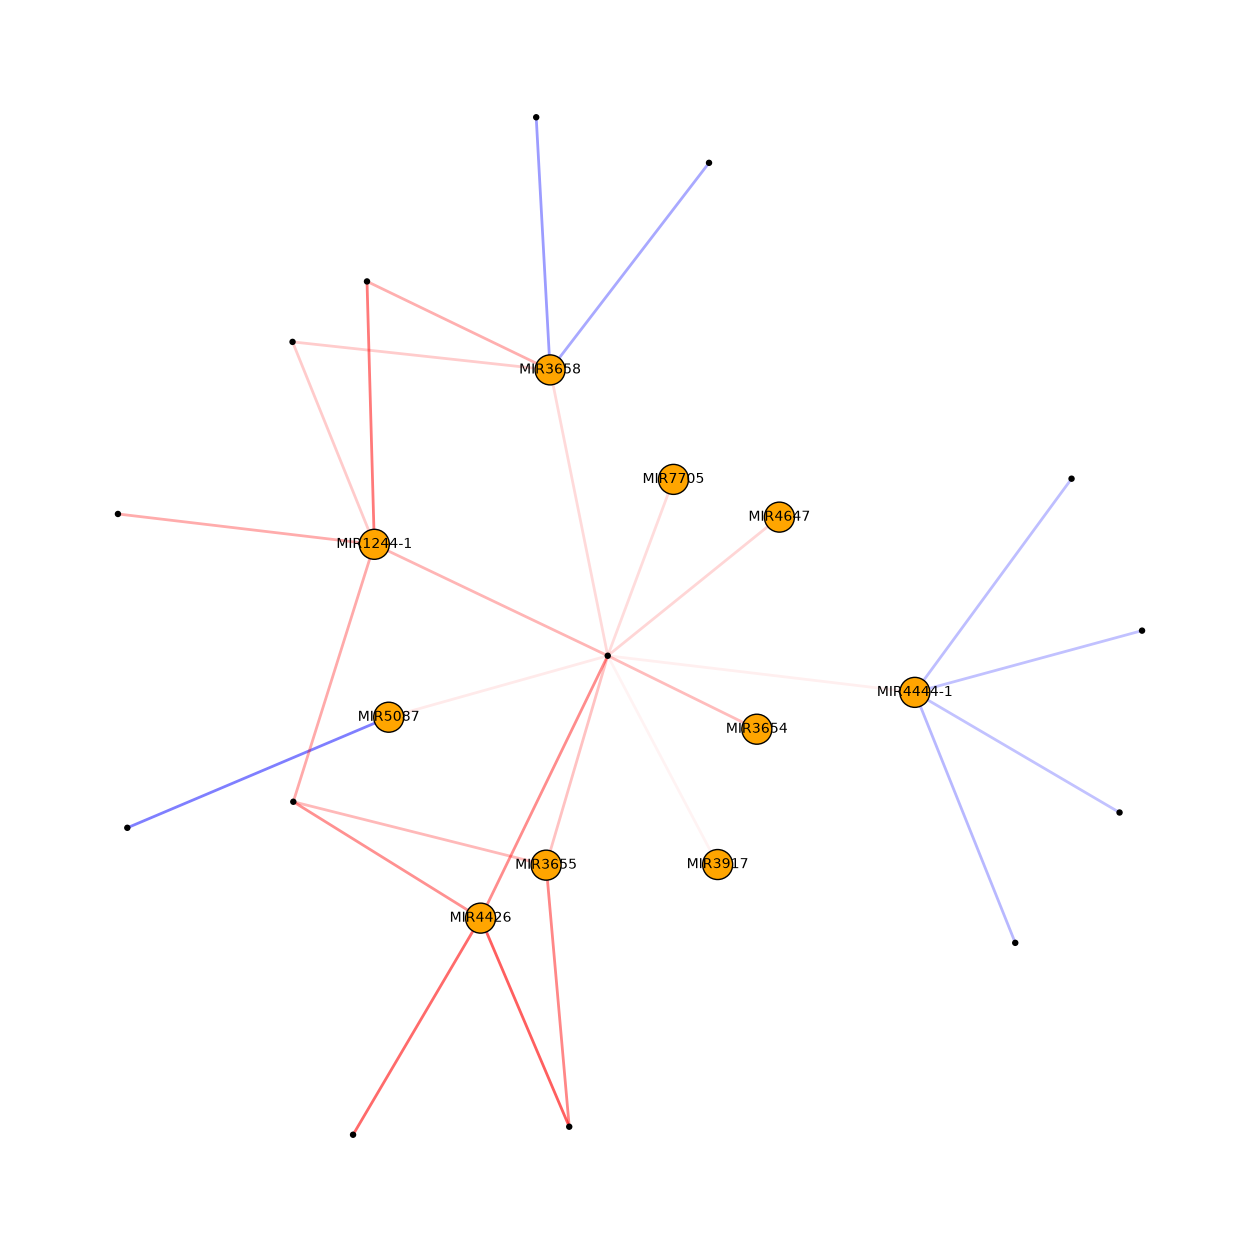

In [229]:
# settings
dataset = "TX"
G1 = np.array([x for x in range(0, 10)])
G2 = np.arange(200)
k, K = 1, 20
d, D = 1, 20
t = 0.0

construct_network(dataset, "All", G1, G2, k, K, d, D, t, plot=True)
construct_network(dataset, "G1", G1, G2, k, K, d, D, t, plot=True)
construct_network(dataset, "S", G1, G2, k, K, d, D, t, plot=True)
construct_network(dataset, "G2M", G1, G2, k, K, d, D, t, plot=True)

## ST

71 edges between 52 vertices


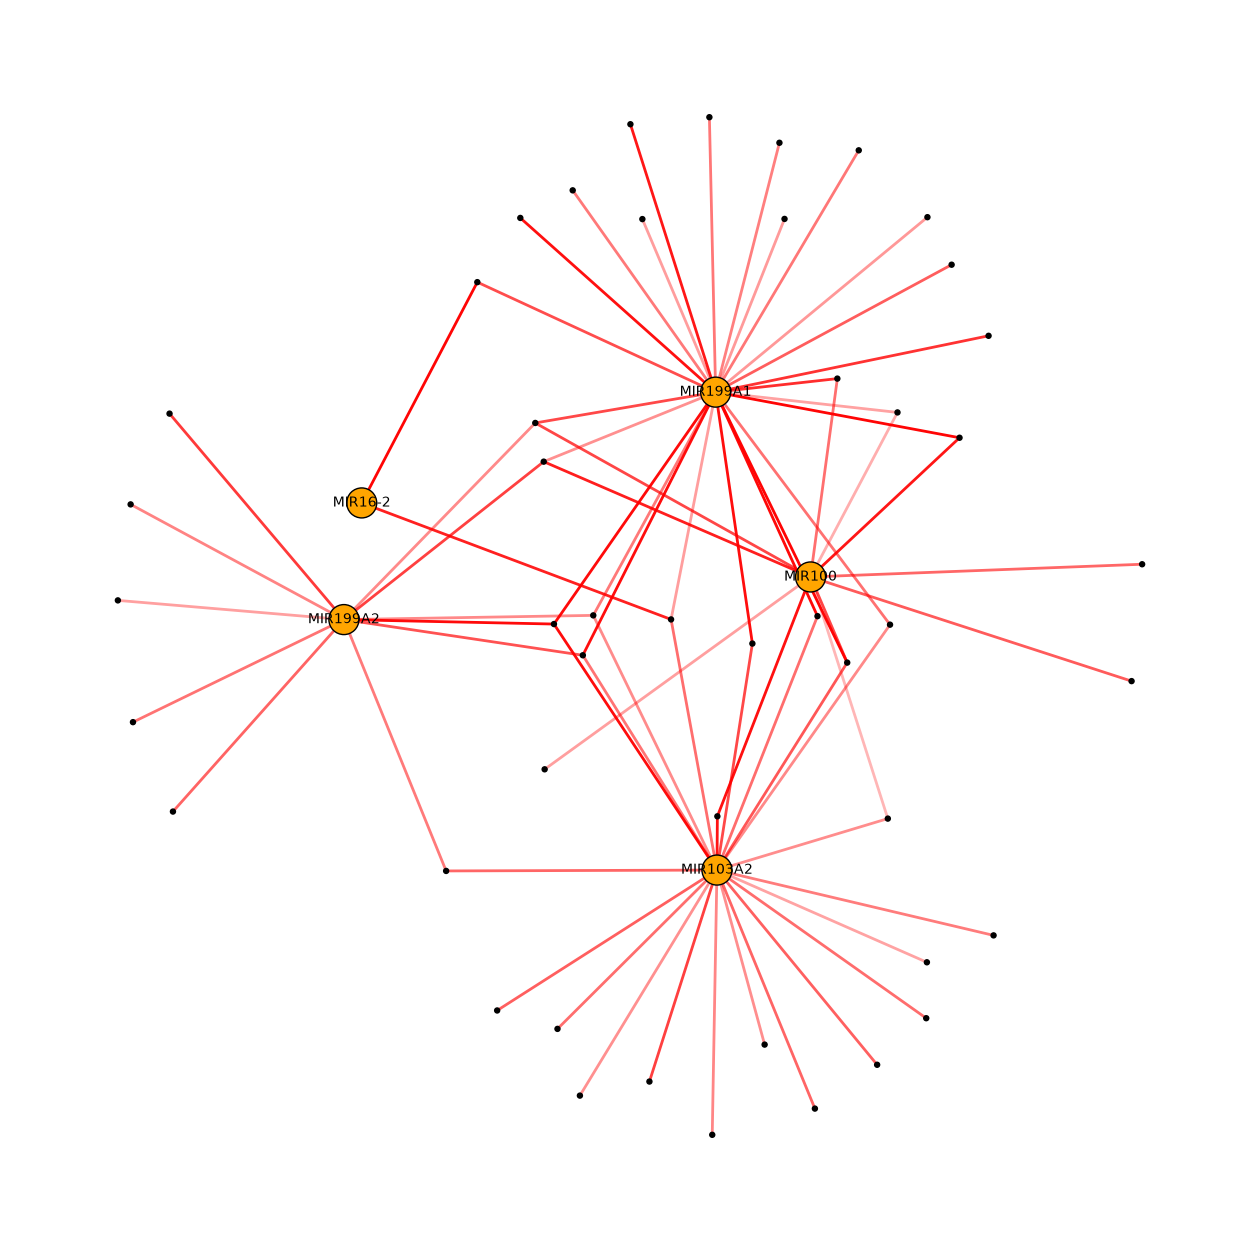

54 edges between 44 vertices


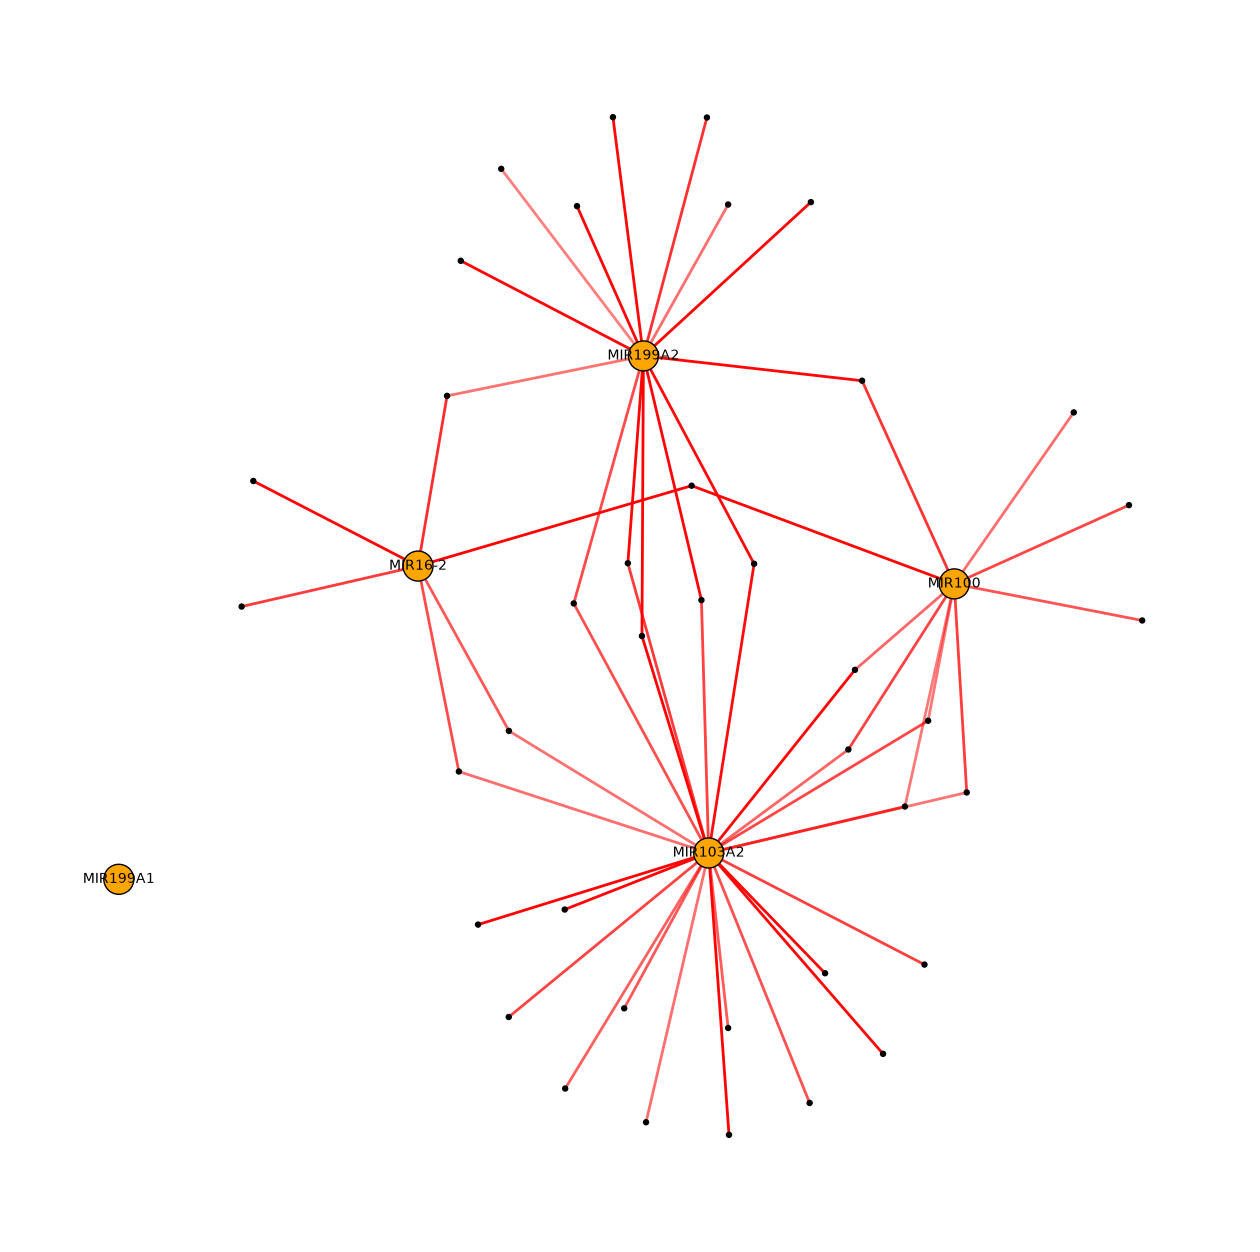

87 edges between 58 vertices


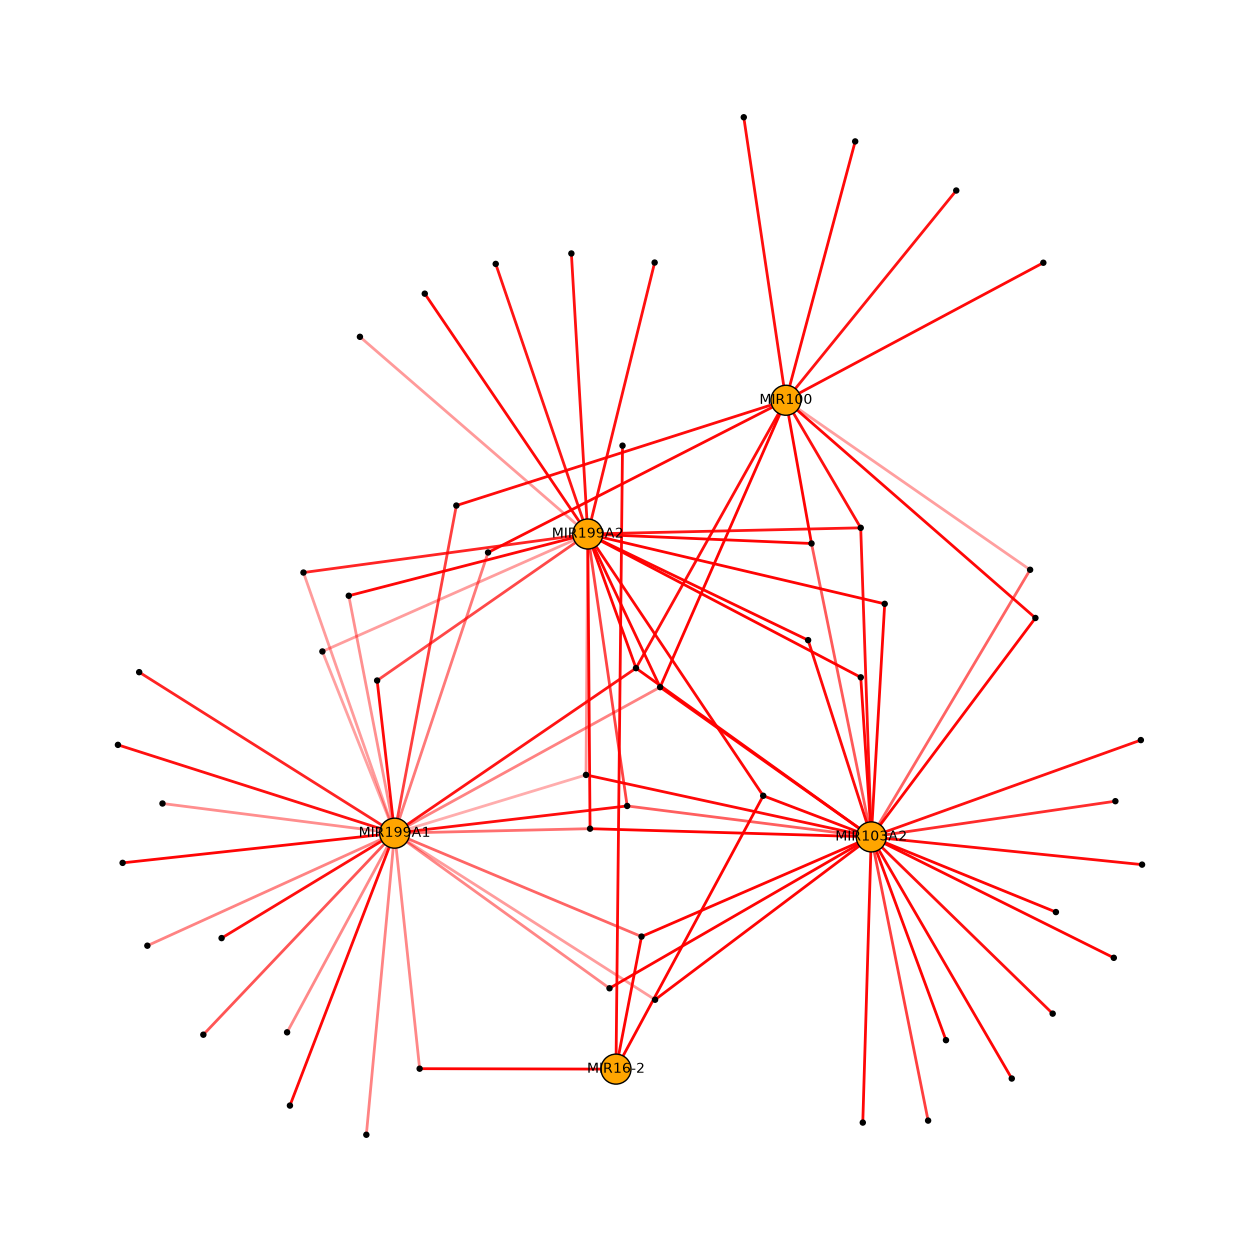

69 edges between 47 vertices


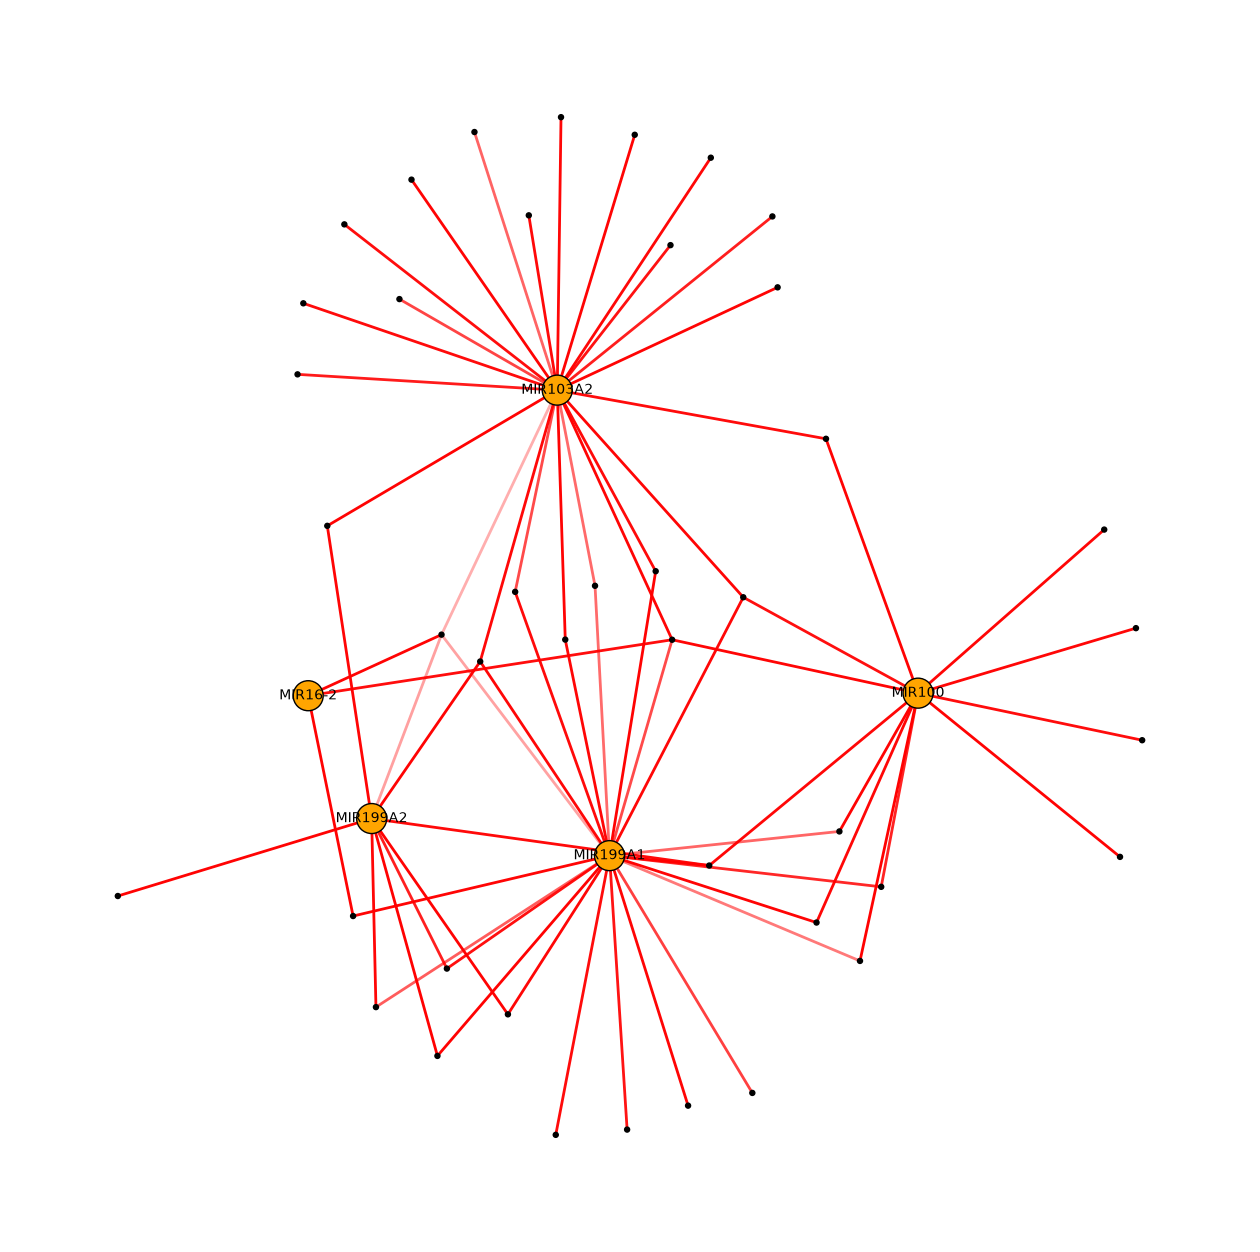

In [230]:
# settings
dataset = "ST"
G1 = np.array([x for x in range(0, 5)])
G2 = np.arange(100)
k, K = 1, 20
d, D = 1, 20
t = 0.0

construct_network(dataset, "All", G1, G2, k, K, d, D, t, plot=True)
construct_network(dataset, "G1", G1, G2, k, K, d, D, t, plot=True)
construct_network(dataset, "S", G1, G2, k, K, d, D, t, plot=True)
construct_network(dataset, "G2M", G1, G2, k, K, d, D, t, plot=True)

# Simulated data

- spurious correlation
- recovered correlation fit

In [104]:
rng = np.random.default_rng(0)

In [171]:
# run size
N = 200
n = 2000

# parameters
mu1 = 10
mu2 = 10
s1 = 5
s2 = 5

mui = 10
si = 5

m = 0.5

counts_OG = np.zeros((N, n, 2), dtype=np.int64)
counts_OB = np.zeros((N, n, 2), dtype=np.int64)

if m == 0:
    beta = np.ones(n)
else:
    b = (1 / m) - 1
    beta = rng.beta(1, b, size=n)

i = 0
for rho in np.linspace(-1, 0.75, N):

    s1 = rng.normal(si, 0.5)
    s2 = rng.normal(si, 0.5)
    mu1 = rng.normal(mui, 2)
    mu2 = rng.normal(mui, 2)

    Sigma = np.array([
        [s1**2, rho*s1*s2],
        [rho*s1*s2, s2**2]
    ])
    mu = np.array([mu1, mu2])

    x_OG = rng.multivariate_normal(mu, Sigma, size=n)
    x_OG = x_OG.astype(np.int64)
    x_OG[x_OG < 0] = 0

    x_OB = rng.binomial(x_OG, beta[:, None]).astype(np.int64)

    counts_OG[i, :, :] = x_OG
    counts_OB[i, :, :] = x_OB

    i += 1

In [172]:
corr_OG = []
corr_OB = []

for i in range(N):

    rho_OG = np.corrcoef(counts_OG[i, :, :].T)[0, 1]
    rho_OB = np.corrcoef(counts_OB[i, :, :].T)[0, 1]

    corr_OG.append(rho_OG)
    corr_OB.append(rho_OB)

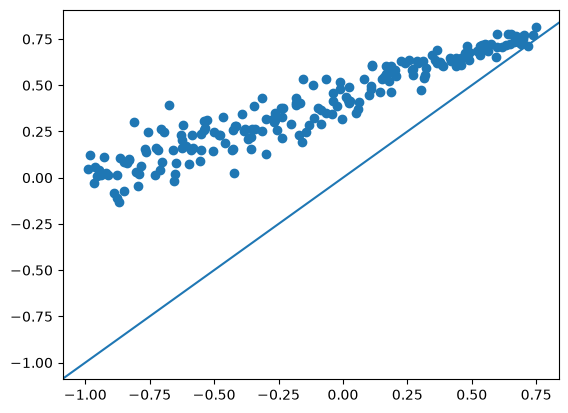

In [173]:
plt.scatter(corr_OG, corr_OB)
plt.axline([-1, -1], [0.75, 0.75])

In [174]:
gene_queries = [
    [[int(i)], [int(i)]] for i in range(N)
]

SDP_data = SDP_miRNA.dataset.Dataset()
SDP_data.construct_dataset_array(
    counts_OB[:, :, 0].T,
    counts_OB[:, :, 1].T,
    beta,
    gene_queries
)
SDP_data.bootstrap(d=3)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00,  5.18it/s]


In [175]:
MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data, d=3)
MF_int.analyse_dataset()

_, HAR_intervals = MF_int.compute_dataset_correlation()
HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

100%|██████████| 200/200 [00:01<00:00, 116.23it/s]


In [177]:
# coverage
mask = (HAR_intervals[:, 0] <= np.array(corr_OG)) & (np.array(corr_OG) <= HAR_intervals[:, 1])
coverage = float(np.mean(mask))

# mse
mse = float(np.mean((np.array(corr_OG) - HAR_mid)**2))

coverage, mse

(0.995, 0.012417810494235015)

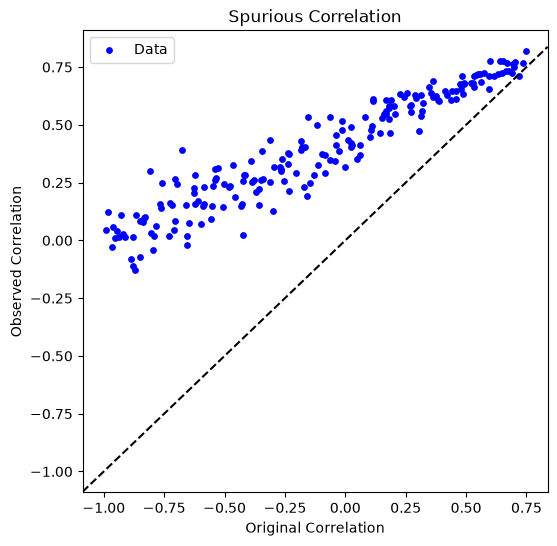

In [178]:
fig, axs = plt.subplots(figsize=(6, 6))
axs.scatter(corr_OG, corr_OB, color="blue", s=15, label="Data")
axs.axline([-1, -1], [0.75, 0.75], color="black", linestyle="--")
axs.set_xlabel("Original Correlation")
axs.set_ylabel("Observed Correlation")
axs.set_title("Spurious Correlation")
axs.legend()
plt.show()

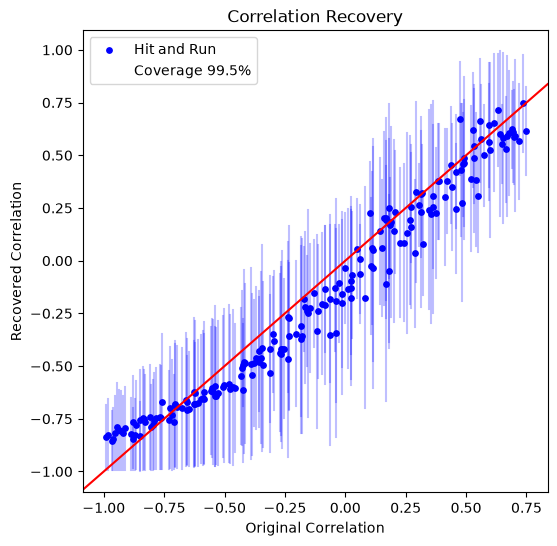

In [184]:
fig, axs = plt.subplots(figsize=(6, 6))
for i in range(N):
    axs.plot([corr_OG[i]]*2, HAR_intervals[i, :], color="blue", alpha=0.25)
axs.scatter(corr_OG, HAR_mid, color="blue", s=15, label="Hit and Run")
axs.axline([-1, -1], [0.75, 0.75], color="red", linestyle="-")
axs.plot([], [], color="white", label=f"Coverage {round(100 * coverage, 2)}%")
#axs.plot([], [], color="white", label=f"MSE {round(mse, 5)}")
axs.set_xlabel("Original Correlation")
axs.set_ylabel("Recovered Correlation")
axs.set_title("Correlation Recovery")
axs.legend()
plt.show()

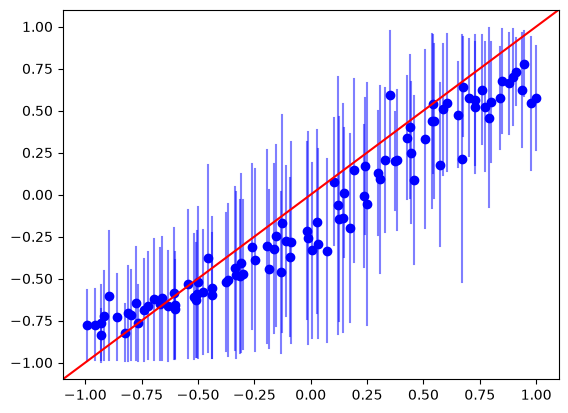

In [116]:
# n = 1,000 cells
for i in range(N):
    plt.plot([corr_OG[i]]*2, HAR_intervals[i, :], color="blue", alpha=0.5)
plt.scatter(corr_OG, HAR_mid, color="blue")
plt.axline([-1, -1], [1, 1], color="red")

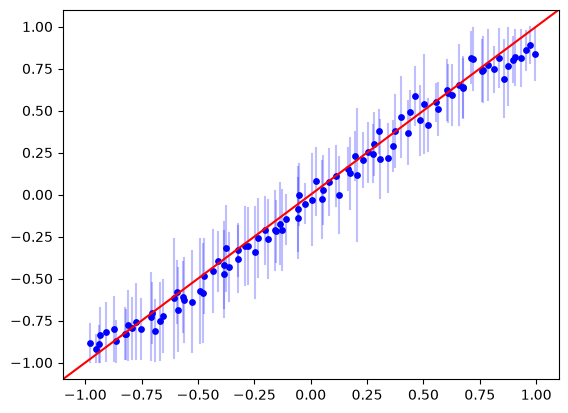

In [125]:
# n = 5,000 cells
for i in range(N):
    plt.plot([corr_OG[i]]*2, HAR_intervals[i, :], color="blue", alpha=0.25)
plt.scatter(corr_OG, HAR_mid, color="blue", s=15)
plt.axline([-1, -1], [1, 1], color="red")

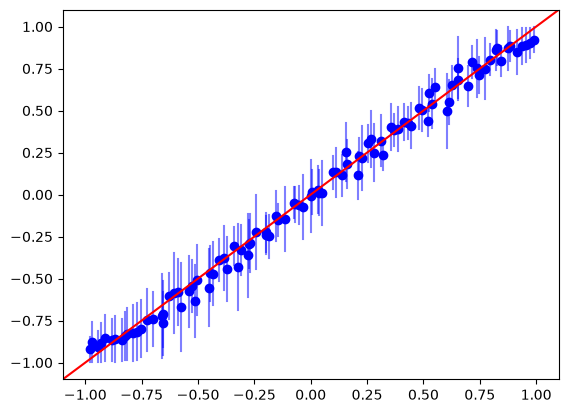

In [ ]:
# n = 10,000 cells
for i in range(N):
    plt.plot([corr_OG[i]]*2, HAR_intervals[i, :], color="blue", alpha=0.5)
plt.scatter(corr_OG, HAR_mid, color="blue")
plt.axline([-1, -1], [1, 1], color="red")